# Polarity separability v2: using the pole scores anyway, at the daily level

**Where we are.** The scorer is reliable on *topics* but not on the *direction* of a single headline:
opposite poles co-move and about half the pairs are close in embedding space. However, the balance of
attention between two poles over a whole day (hundreds of headlines) tilts the expected way in most
known-direction episodes (22/27 in `evergreen_tax_polar_narr.ipynb`).

**Rule implemented here** (no scorer change, no re-score; reads the existing pole-level panel):

1. per pole and day, score θ = attention = TOTAL_SCORE / N_HEADLINES;
2. per bipolar pair and day, balance b = (θ_A − θ_B) / (θ_A + θ_B) ∈ [−1, 1];
3. **confidence** c ∈ [0, 1] = how far b is from the pair's own normal balance, relative to the pair's
   own day-to-day noise: c = clip(|b − m| / (K · s), 0, 1), with m, s the median and robust sd of b
   over the previous `TRAIL_DAYS` (strictly past). Days with fewer than `MIN_SUPPORT` supporting
   headlines get c = 0;
4. **direction label** = sign(b − m) when c ≥ `THRESH`, else **NaN ("unclear"), never 0**;
5. **un-polar (topic) column**: max(θ_A, θ_B) when c ≥ `THRESH`, else (θ_A + θ_B) / 2;
6. **poles when unclear**: both pulled to the pair mean, weighted by confidence:
   θ_i* = mean + w · (θ_i − mean), w = c (`SHRINK="confidence"`) or w = 1{c ≥ THRESH} (`"hard"`).

Then a short validation on three crises (GFC, Covid, 2022 inflation / tightening): does the daily label
point the expected way in declared episodes, how often does it abstain, which pairs are usable.
Episodes are declared in the config cell before any result. Read-only on the datalake.

In [2]:
import os
from datetime import date, timedelta

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
from dotenv import find_dotenv, load_dotenv

from datalake import DatalakeIndex

load_dotenv(find_dotenv(usecwd=True))
pl.Config.set_tbl_rows(60); pl.Config.set_tbl_width_chars(230); pl.Config.set_fmt_str_lengths(60)
pl.Config.set_tbl_cols(20)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.constrained_layout.use": True})

TAXONOMY = "Evergreen_v5"
NARRATIVE_DAILY_ID = None      # None = newest non-deprecated pole-level (category) run of TAXONOMY
KEY = "narrative_key"

# ---- the rule --------------------------------------------------------------------------------
THRESH = 2 / 3                 # confidence needed to keep a direction / to use max() for the topic
K = 3.0                        # c = 1 at 3 robust sd; with THRESH = 2/3 a label needs >= 2 robust sd
TRAIL_DAYS = 365               # trailing window (calendar days, strictly past) for m and s
MIN_TRAIL = 120                # days with a balance needed in the window before any confidence
MIN_SUPPORT = 20               # supporting headlines (both poles) needed on a day
SHRINK = "confidence"          # "confidence" | "hard"

# ---- validation --------------------------------------------------------------------------------
CRISES = {"GFC": (date(2007, 7, 1), date(2009, 6, 30)),
          "Covid": (date(2020, 2, 1), date(2021, 6, 30)),
          "2022 inflation / tightening": (date(2021, 6, 1), date(2023, 12, 31))}
CALM = (date(2013, 1, 1), date(2017, 12, 31))       # abstention calibration: no big shock
USABLE_MIN_DAYS = 30           # confident episode days needed to judge a pair
USABLE_HIT = 0.65              # hit rate needed to call a pair usable

# (pole expected to dominate, its sibling, start, end); GFC/Covid from the polar notebook, 2022 added
EPISODES = [
    ("housing-bust", "housing-boom", date(2007, 7, 1), date(2009, 6, 30)),
    ("bank-balance-sheet-impairment", "bank-balance-sheet-repair", date(2007, 8, 1), date(2009, 3, 31)),
    ("credit-supply-tightening", "credit-supply-expansion", date(2007, 8, 1), date(2009, 6, 30)),
    ("rating-downgrade", "rating-upgrade", date(2008, 9, 1), date(2009, 6, 30)),
    ("credit-deterioration", "credit-strengthening", date(2008, 9, 1), date(2009, 3, 31)),
    ("credit-spread-plumbing-widening", "credit-spread-plumbing-tightening", date(2008, 9, 1), date(2009, 3, 31)),
    ("business-cycle-contraction", "business-cycle-expansion", date(2008, 9, 1), date(2009, 6, 30)),
    ("labour-market-slackening", "labour-market-tightening", date(2008, 10, 1), date(2009, 6, 30)),
    ("global-liquidity-easing", "global-liquidity-tightening", date(2008, 10, 1), date(2009, 6, 30)),
    ("balance-sheet-expansion", "balance-sheet-contraction", date(2008, 11, 1), date(2009, 6, 30)),
    ("demand-destruction", "demand-surge", date(2008, 10, 1), date(2009, 3, 31)),
    ("price-level-change-disinflation", "price-level-change-reflation", date(2008, 10, 1), date(2009, 6, 30)),
    ("public-health-deterioration", "public-health-improvement", date(2020, 2, 1), date(2020, 5, 31)),
    ("business-cycle-contraction", "business-cycle-expansion", date(2020, 3, 1), date(2020, 5, 31)),
    ("demand-destruction", "demand-surge", date(2020, 3, 1), date(2020, 5, 31)),
    ("dividend-cut", "dividend-initiation", date(2020, 3, 1), date(2020, 6, 30)),
    ("guidance-cut", "guidance-raise", date(2020, 3, 1), date(2020, 5, 31)),
    ("rating-downgrade", "rating-upgrade", date(2020, 3, 1), date(2020, 6, 30)),
    ("labour-market-slackening", "labour-market-tightening", date(2020, 3, 1), date(2020, 6, 30)),
    ("public-health-improvement", "public-health-deterioration", date(2020, 11, 9), date(2021, 4, 30)),
    ("price-level-change-reflation", "price-level-change-disinflation", date(2021, 6, 1), date(2022, 6, 30)),
    ("input-cost-squeeze", "input-cost-relief", date(2021, 6, 1), date(2022, 6, 30)),
    ("labour-market-tightening", "labour-market-slackening", date(2021, 6, 1), date(2022, 12, 31)),
    ("global-liquidity-tightening", "global-liquidity-easing", date(2022, 3, 1), date(2023, 6, 30)),
    ("balance-sheet-contraction", "balance-sheet-expansion", date(2022, 6, 1), date(2023, 12, 31)),
    ("bank-balance-sheet-impairment", "bank-balance-sheet-repair", date(2023, 3, 8), date(2023, 5, 31)),
    ("credit-supply-tightening", "credit-supply-expansion", date(2023, 3, 8), date(2023, 9, 30)),
]

# batteries redone on the un-polar columns (category names; poles are replaced by their pair's topic)
BATTERIES = {
    "GFC": {"bank intermediation": ["bank-balance-sheet-impairment", "credit-supply-tightening", "credit-crunch-salience"],
            "real economy": ["business-cycle-contraction", "labour-market-slackening", "credit-contraction",
                             "hard-landing", "default-cycle-deterioration"],
            "housing": ["housing-bust"]},
    "Covid": {"health": ["public-health-deterioration", "pandemic-and-epidemic-outbreak",
                         "health-fear-and-contagion-salience"],
              "real contraction": ["business-cycle-contraction", "labour-market-slackening", "guidance-cut",
                                   "dividend-cut", "demand-retrenchment"]},
    "2022 inflation / tightening": {"inflation": ["price-level-change-reflation", "accelerating-inflation",
                                                  "input-cost-squeeze", "wage-growth-pressure"],
                                    "tightening": ["global-liquidity-tightening", "balance-sheet-contraction",
                                                   "rate-tightening-cycle", "hawkish-guidance-shift"]},
}
BASELINE_YEARS = 2             # battery ratio baseline: the 2 years before each crisis

## 1. Data: pole-level panel and the 51 pairs

A pair is two categories sharing `TOPIC / GROUP / TYPE` in the registered taxonomy (they differ only by
`SUB_TYPE`, the pole). Orientation inside a pair is alphabetical; the label +1 means "pole a dominates".

In [3]:
dl = DatalakeIndex(os.environ["DATALAKE_ROOT"], create=False)
up_root = os.environ.get("DATALAKE_UPSTREAM_ROOT")
up = DatalakeIndex(up_root, create=False) if up_root else dl
if NARRATIVE_DAILY_ID is not None:
    ART = dl.get(NARRATIVE_DAILY_ID)
else:
    ART = [a for a in dl.list("narrative_daily")
           if a.meta.hyperparams.get("taxonomy_name") == TAXONOMY
           and a.meta.hyperparams.get("narrative_level", "category") == "category"][0]
hp = ART.meta.hyperparams
TAX_ART = next(x for x in (dl, up) if x.exists(hp["taxonomy_artifact_id"])).get(hp["taxonomy_artifact_id"])
print("panel   :", ART.artifact_id, "| partial:", ART.partial)
print("taxonomy:", TAX_ART.artifact_id)

tx = (pl.read_csv(TAX_ART.path / f"{TAXONOMY}_taxonomy.authored.csv", infer_schema_length=0)
      .select("TOPIC", "GROUP", "TYPE", "SUB_TYPE", "CATEGORY").unique()
      .with_columns(pl.col("SUB_TYPE").fill_null("")))
grp = (tx.filter(pl.col("SUB_TYPE") != "").group_by("TOPIC", "GROUP", "TYPE")
       .agg(pl.col("CATEGORY").sort().alias("cats")).filter(pl.col("cats").list.len() == 2))
PAIRS = pl.DataFrame([{"pair": f"{r['GROUP']}:{r['TYPE']}", "reservoir": r["TOPIC"], "a": r["cats"][0], "b": r["cats"][1],
                       "key_a": f"{r['TOPIC']}|{r['GROUP']}|{r['cats'][0]}", "key_b": f"{r['TOPIC']}|{r['GROUP']}|{r['cats'][1]}"}
                      for r in grp.iter_rows(named=True)]).sort("reservoir", "pair")
print(f"{PAIRS.height} bipolar pairs")

FILES = sorted(ART.path.glob("[12][0-9][0-9][0-9]-[01][0-9].parquet"))
daily = (pl.scan_parquet([str(f) for f in FILES]).filter(pl.col("SENTIMENT") == "all")
         .select("DATE", "narrative", KEY, "SUPPORT", "TOTAL_SCORE", "N_HEADLINES")
         .with_columns(pl.when(pl.col("N_HEADLINES") > 0)
                       .then(pl.col("TOTAL_SCORE").fill_null(0.0) / pl.col("N_HEADLINES")).alias("THETA"))
         .collect())
KEYS = sorted(daily[KEY].unique().to_list())
kidx = {k: i for i, k in enumerate(KEYS)}
assert set(PAIRS["key_a"]) | set(PAIRS["key_b"]) <= set(KEYS), "pair keys missing from the panel"
wide = lambda col: daily.pivot(on=KEY, index="DATE", values=col).sort("DATE")
_w = wide("THETA"); DATES = np.array(_w["DATE"].to_list()); TH = _w.select(KEYS).to_numpy()
SUP = wide("SUPPORT").select(KEYS).to_numpy().astype(float)
name_keys = {}
for k in KEYS:
    name_keys.setdefault(k.split("|")[-1], []).append(k)
print(f"{len(DATES)} days {DATES[0]} .. {DATES[-1]}, {len(KEYS)} narratives")

panel   : narrative_daily__v2.2.0__params0a029753__20260927 | partial: False
taxonomy: narrative_taxonomy__v2.1.0__paramsbf25ede9__20260923
51 bipolar pairs
9406 days 2000-04-01 .. 2025-12-31, 419 narratives


## 2. Pole difference and balance

d = θ_a − θ_b and b = d / (θ_a + θ_b). b removes the level of the topic (which moves with the feed and
with crises) and keeps only the split between the poles. Most pairs have a structural bias (one pole is
usually larger), which is why the confidence below is measured against the pair's own normal balance.

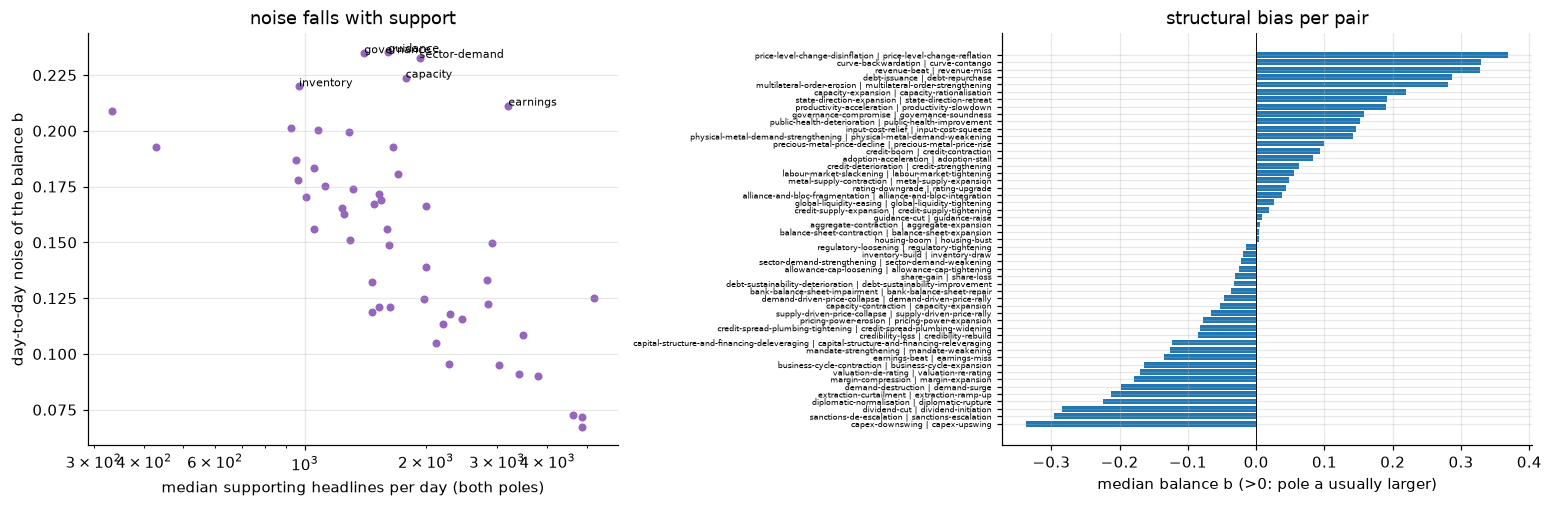

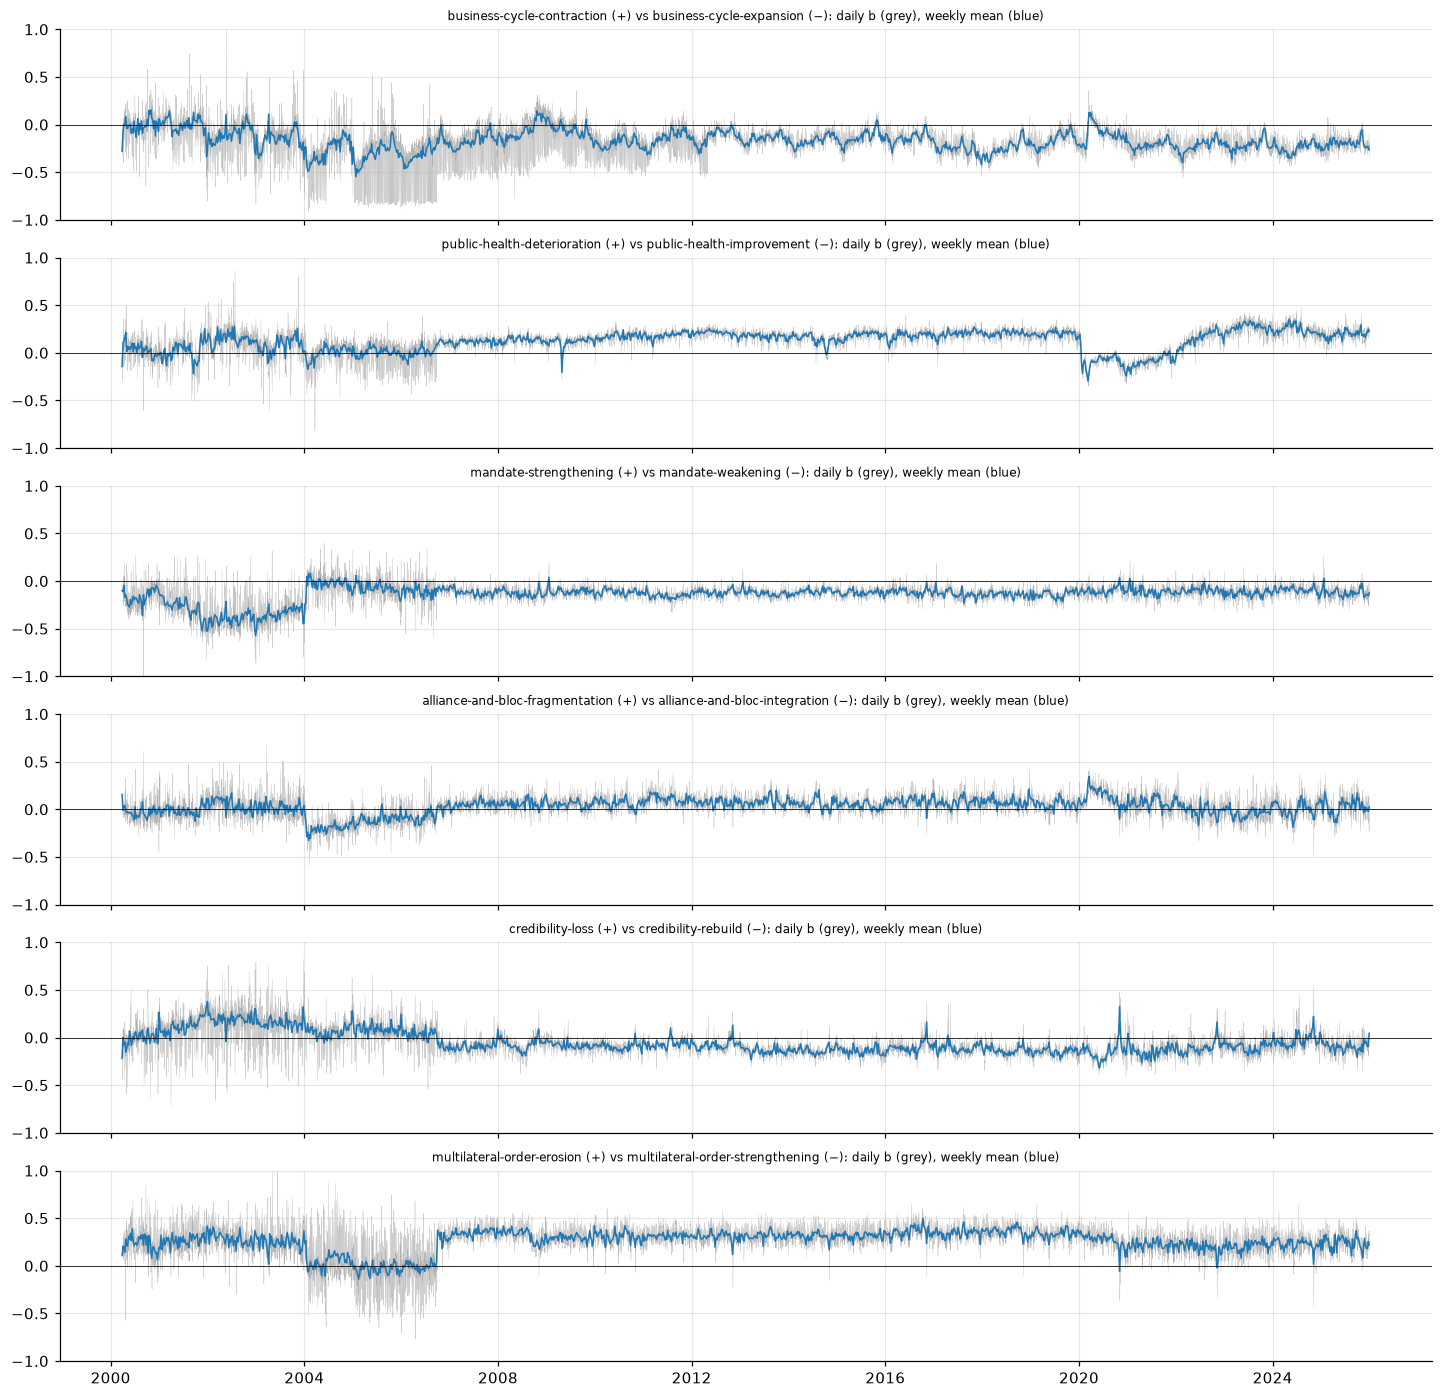

pair,a,b,median_support,median_balance,sd_balance,day_to_day_sd
str,str,str,f64,f64,f64,f64
"""inventory-and-buffer-state:inventory""","""inventory-build""","""inventory-draw""",969.0,-0.019,0.268,0.22
"""precious-metal-physical-state:metal-supply""","""metal-supply-contraction""","""metal-supply-expansion""",1659.5,0.048,0.235,0.193
"""precious-metal-physical-state:physical-metal-demand""","""physical-metal-demand-strengthening""","""physical-metal-demand-weakening""",1011.0,0.142,0.231,0.17
"""precious-metal-physical-state:precious-metal-price""","""precious-metal-price-decline""","""precious-metal-price-rise""",1054.5,0.099,0.222,0.183
"""resource-demand-condition:demand""","""demand-destruction""","""demand-surge""",1238.5,-0.199,0.209,0.166
"""resource-price-and-volatility:curve""","""curve-backwardation""","""curve-contango""",333.5,0.329,0.242,0.209
"""resource-price-and-volatility:demand-driven-price""","""demand-driven-price-collapse""","""demand-driven-price-rally""",1532.5,-0.047,0.235,0.172
"""resource-price-and-volatility:supply-driven-price""","""supply-driven-price-collapse""","""supply-driven-price-rally""",1297.0,-0.066,0.193,0.151
"""resource-supply-condition:capacity""","""capacity-contraction""","""capacity-expansion""",1781.0,-0.053,0.264,0.224


In [4]:
ia = np.array([kidx[k] for k in PAIRS["key_a"]]); ib = np.array([kidx[k] for k in PAIRS["key_b"]])
A, B = TH[:, ia], TH[:, ib]                                  # days x pairs
S = SUP[:, ia] + SUP[:, ib]                                  # supporting headlines (a headline in both counts twice)
D = A - B
with np.errstate(invalid="ignore", divide="ignore"):
    BAL = np.where(A + B > 0, D / (A + B), np.nan)
assert np.nanmin(BAL) >= -1 - 1e-9 and np.nanmax(BAL) <= 1 + 1e-9

summ = PAIRS.with_columns(
    pl.Series("mean_theta_a", np.nanmean(A, axis=0)), pl.Series("mean_theta_b", np.nanmean(B, axis=0)),
    pl.Series("median_balance", np.nanmedian(BAL, axis=0)), pl.Series("sd_balance", np.nanstd(BAL, axis=0)),
    pl.Series("median_support", np.nanmedian(S, axis=0)),
    pl.Series("day_to_day_sd", np.nanstd(np.diff(BAL, axis=0), axis=0) / np.sqrt(2)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].scatter(summ["median_support"], summ["day_to_day_sd"], s=18, color="tab:purple")
for r in summ.sort("day_to_day_sd", descending=True).head(6).iter_rows(named=True):
    axes[0].annotate(r["pair"].split(":")[1], (r["median_support"], r["day_to_day_sd"]), fontsize=7)
axes[0].set_xscale("log"); axes[0].set_xlabel("median supporting headlines per day (both poles)")
axes[0].set_ylabel("day-to-day noise of the balance b"); axes[0].set_title("noise falls with support")
o = summ.sort("median_balance")
axes[1].barh(np.arange(o.height), o["median_balance"], color="tab:blue")
axes[1].set_yticks(np.arange(o.height), [f"{a} | {b}" for a, b in zip(o["a"], o["b"])], fontsize=5)
axes[1].axvline(0, color="k", lw=0.6); axes[1].set_xlabel("median balance b (>0: pole a usually larger)")
axes[1].set_title("structural bias per pair")
plt.show()

show = summ.sort("median_support", descending=True).head(6)["pair"].to_list()
fig, axes = plt.subplots(len(show), 1, figsize=(13, 2.1 * len(show)), sharex=True)
wk = pl.Series("W", DATES.tolist(), dtype=pl.Date).dt.truncate("1w")          # Monday of each day's week
for ax, p in zip(axes, show):
    j = PAIRS["pair"].to_list().index(p)
    s = pl.DataFrame({"W": wk, "b": BAL[:, j]}).group_by("W").agg(pl.col("b").mean()).sort("W")
    ax.plot(DATES, BAL[:, j], lw=0.2, color="0.7"); ax.plot(s["W"], s["b"], lw=1, color="tab:blue")
    ax.axhline(0, color="k", lw=0.5); ax.set_ylim(-1, 1)
    ax.set_title(f"{PAIRS['a'][j]} (+) vs {PAIRS['b'][j]} (−): daily b (grey), weekly mean (blue)", fontsize=8)
plt.show()
summ.select("pair", "a", "b", "median_support", "median_balance", "sd_balance", "day_to_day_sd").with_columns(pl.selectors.float().round(3))

## 3. Confidence and direction label

m, s = trailing median and robust sd (IQR / 1.349) of the pair's balance over the previous
`TRAIL_DAYS` days, **excluding the day itself** (point-in-time). c = clip(|b − m| / (K · s), 0, 1);
c = 0 when support < `MIN_SUPPORT`, when b is undefined or when the window is too short.
Label = sign(b − m) if c ≥ `THRESH`, else NaN.

confident (labelled) days: 8.3% overall; per pair median 8.0%, range 5.6% .. 11.5%
confident days in the calm period 2013-01-01..2017-12-31: 7.9% (what the threshold lets through without a shock)


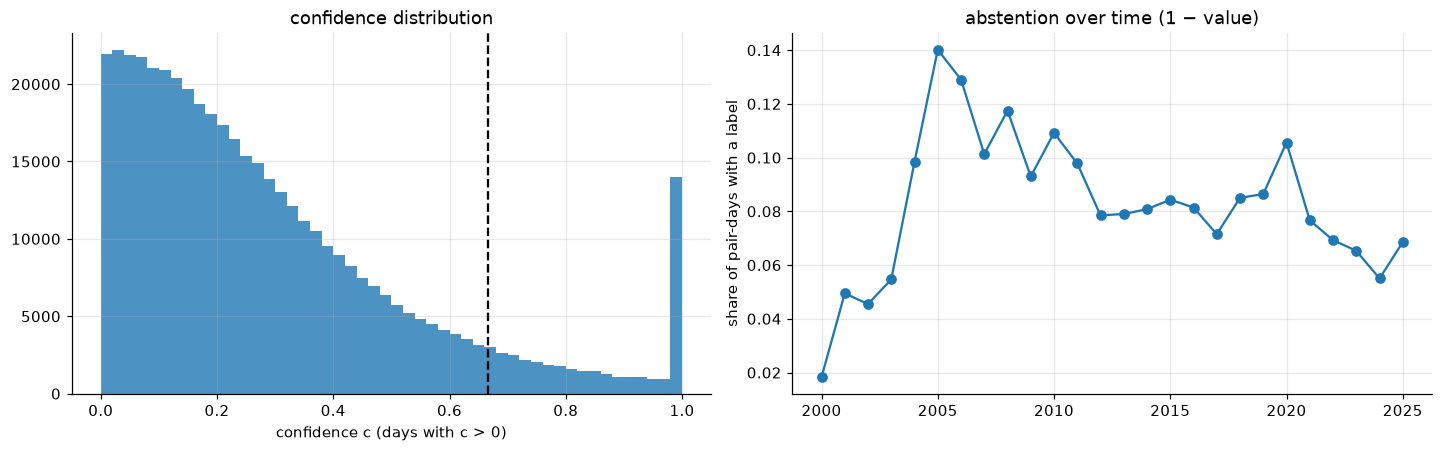

In [5]:
bdf = pl.DataFrame({f"p{j}": BAL[:, j] for j in range(PAIRS.height)}).with_columns(pl.all().fill_nan(None))
roll = lambda e: [e(pl.col(c)).shift(1).alias(c) for c in bdf.columns]
opts = dict(window_size=TRAIL_DAYS, min_samples=MIN_TRAIL)
MED = bdf.select(roll(lambda c: c.rolling_median(**opts))).to_numpy().astype(float)
Q75 = bdf.select(roll(lambda c: c.rolling_quantile(0.75, **opts))).to_numpy().astype(float)
Q25 = bdf.select(roll(lambda c: c.rolling_quantile(0.25, **opts))).to_numpy().astype(float)
RSD = (Q75 - Q25) / 1.349
DEV = BAL - MED
with np.errstate(invalid="ignore", divide="ignore"):
    CONF = np.clip(np.abs(DEV) / (K * RSD), 0.0, 1.0)
CONF[~np.isfinite(CONF) | ~(RSD > 1e-12) | (S < MIN_SUPPORT)] = 0.0
LABEL = np.where(CONF >= THRESH, np.sign(DEV), np.nan)
assert not (LABEL == 0).any(), "a label is 0: unclear must be NaN"
assert ((CONF >= 0) & (CONF <= 1)).all()

conf_share = np.mean(~np.isnan(LABEL), axis=0)
print(f"confident (labelled) days: {np.mean(~np.isnan(LABEL)):.1%} overall; per pair median {np.median(conf_share):.1%}, "
      f"range {conf_share.min():.1%} .. {conf_share.max():.1%}")
calm = (DATES >= CALM[0]) & (DATES <= CALM[1])
print(f"confident days in the calm period {CALM[0]}..{CALM[1]}: {np.mean(~np.isnan(LABEL[calm])):.1%} "
      f"(what the threshold lets through without a shock)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(CONF[CONF > 0].ravel(), bins=50, color="tab:blue", alpha=0.8); axes[0].axvline(THRESH, color="k", ls="--")
axes[0].set_xlabel("confidence c (days with c > 0)"); axes[0].set_title("confidence distribution")
yr = np.array([d.year for d in DATES])
axes[1].plot(np.unique(yr), [np.mean(~np.isnan(LABEL[yr == y])) for y in np.unique(yr)], marker="o")
axes[1].set_ylabel("share of pair-days with a label"); axes[1].set_title("abstention over time (1 − value)")
plt.show()

## 4. Un-polar (topic) column and shrunk poles

Topic = max(θ_a, θ_b) when c ≥ `THRESH`, else (θ_a + θ_b) / 2. For reference: max(θ_a, θ_b) is a lower
bound of the true merged attention (a headline in either pole) and θ_a + θ_b an upper bound (it double
counts headlines assigned to both poles). The rule switches between max and mean, so it drops when the
direction becomes unclear; the plot shows how much.

topic / max(θa, θb), time average per pair: median 0.878, min 0.752


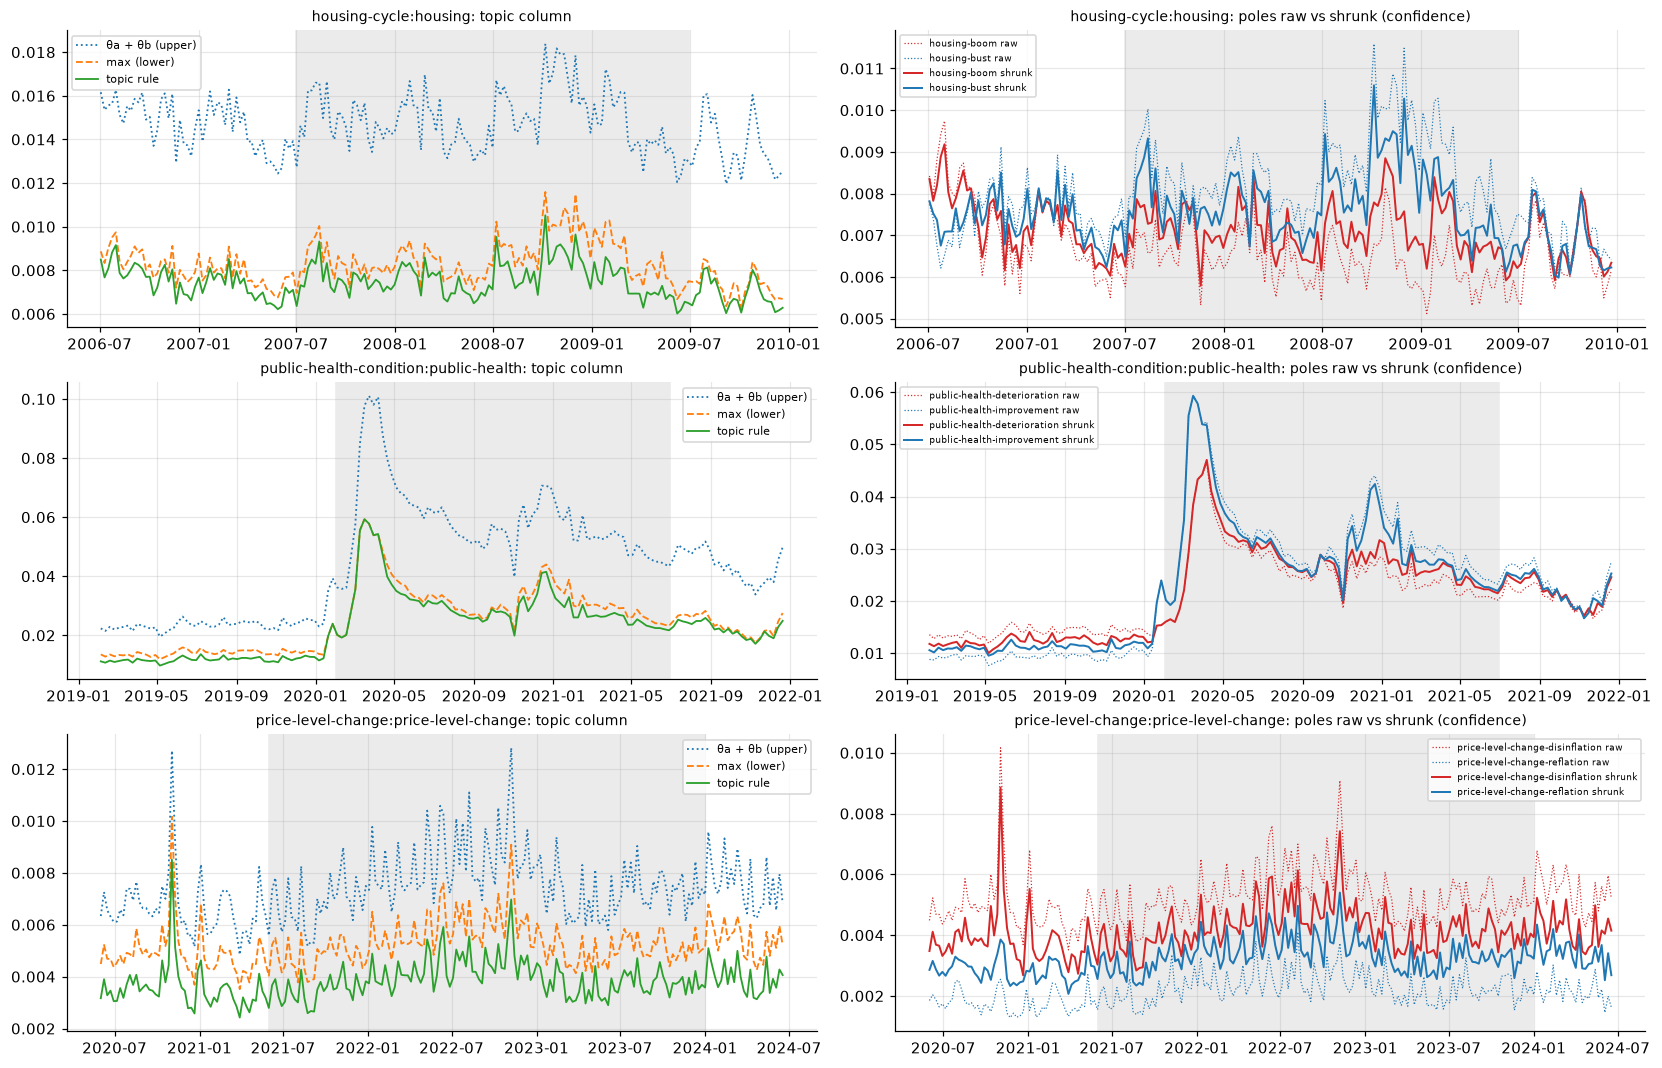

In [6]:
TOPIC = np.where(CONF >= THRESH, np.maximum(A, B), (A + B) / 2)
MEAN = (A + B) / 2
W = CONF if SHRINK == "confidence" else (CONF >= THRESH).astype(float)
A_STAR, B_STAR = MEAN + W * (A - MEAN), MEAN + W * (B - MEAN)
assert np.allclose(A_STAR + B_STAR, A + B, equal_nan=True)     # shrinking moves attention between poles only

rel = np.nanmean(TOPIC, axis=0) / np.nanmean(np.maximum(A, B), axis=0)
print(f"topic / max(θa, θb), time average per pair: median {np.nanmedian(rel):.3f}, min {np.nanmin(rel):.3f}")


def weekly(x):
    s = pl.DataFrame({"W": wk, "x": x}).group_by("W").agg(pl.col("x").mean()).sort("W")
    return s["W"].to_numpy(), s["x"].to_numpy()


ex = [("housing-bust", CRISES["GFC"]), ("public-health-deterioration", CRISES["Covid"]),
      ("price-level-change-reflation", CRISES["2022 inflation / tightening"])]
fig, axes = plt.subplots(len(ex), 2, figsize=(15, 3.2 * len(ex)))
for (p, (lo, hi)), row in zip(ex, axes):
    j = next(i for i, (a_, b_) in enumerate(zip(PAIRS["a"], PAIRS["b"])) if p in (a_, b_))
    p = PAIRS["pair"][j]
    m = (DATES >= lo - timedelta(days=365)) & (DATES <= hi + timedelta(days=180))
    for x, lab, st in ((A[:, j] + B[:, j], "θa + θb (upper)", ":"), (np.maximum(A[:, j], B[:, j]), "max (lower)", "--"),
                       (TOPIC[:, j], "topic rule", "-")):
        w_, v_ = weekly(np.where(m, x, np.nan)); keep = ~np.isnan(v_)
        row[0].plot(w_[keep], v_[keep], ls=st, lw=1.2, label=lab)
    row[0].axvspan(lo, hi, color="0.92"); row[0].legend(fontsize=7); row[0].set_title(f"{p}: topic column", fontsize=9)
    for x, lab, col in ((A[:, j], PAIRS["a"][j], "tab:red"), (B[:, j], PAIRS["b"][j], "tab:blue")):
        w_, v_ = weekly(np.where(m, x, np.nan)); keep = ~np.isnan(v_)
        row[1].plot(w_[keep], v_[keep], color=col, lw=0.8, ls=":", label=f"{lab} raw")
    for x, lab, col in ((A_STAR[:, j], PAIRS["a"][j], "tab:red"), (B_STAR[:, j], PAIRS["b"][j], "tab:blue")):
        w_, v_ = weekly(np.where(m, x, np.nan)); keep = ~np.isnan(v_)
        row[1].plot(w_[keep], v_[keep], color=col, lw=1.3, label=f"{lab} shrunk")
    row[1].axvspan(lo, hi, color="0.92"); row[1].legend(fontsize=6); row[1].set_title(f"{p}: poles raw vs shrunk ({SHRINK})", fontsize=9)
plt.show()

## 5. Validation

### 5.1 Declared episodes: does the daily label point the expected way?

Per episode: share of days with a label (the rest abstain) and, among labelled days, the share pointing
the expected way (hit rate). 50 % is a coin flip.

In [7]:
pair_of = {}
for j, r in enumerate(PAIRS.iter_rows(named=True)):
    pair_of[r["a"]] = (j, +1); pair_of[r["b"]] = (j, -1)
crisis_of = lambda s, e: next((n for n, (lo, hi) in CRISES.items() if s <= hi and e >= lo), "other")
ep_rows = []
for up_, down_, s, e in EPISODES:
    if e > DATES[-1]:
        print("skipped (beyond the panel):", up_, s, e); continue
    j, sign_up = pair_of[up_]
    assert pair_of[down_][0] == j, (up_, down_)
    m = (DATES >= s) & (DATES <= e)
    lab = LABEL[m, j]; hit = lab[~np.isnan(lab)] == sign_up
    ep_rows.append({"crisis": crisis_of(s, e), "expected": f"{up_} > {down_}", "window": f"{s:%Y-%m}..{e:%Y-%m}",
                    "days": int(m.sum()), "labelled_share": float(np.mean(~np.isnan(lab))),
                    "labelled_days": int(hit.size), "hit_rate": float(hit.mean()) if hit.size else np.nan,
                    "pair": PAIRS["pair"][j]})
EPT = pl.DataFrame(ep_rows)
display(EPT.with_columns(pl.selectors.float().round(3)))
tot = EPT.filter(pl.col("labelled_days") > 0)
w_hit = (tot["hit_rate"] * tot["labelled_days"]).sum() / tot["labelled_days"].sum()
print(f"episodes: {EPT.height}; labelled-day-weighted hit rate {w_hit:.1%}; "
      f"episodes with hit rate > 50 %: {(tot['hit_rate'] > 0.5).sum()}/{tot.height}")
print(EPT.group_by("crisis").agg(pl.col("labelled_days").sum(),
                                 ((pl.col("hit_rate") * pl.col("labelled_days")).sum() / pl.col("labelled_days").sum()).alias("hit_rate"))
      .sort("crisis"))

crisis,expected,window,days,labelled_share,labelled_days,hit_rate,pair
str,str,str,i64,f64,i64,f64,str
"""GFC""","""housing-bust > housing-boom""","""2007-07..2009-06""",731,0.078,57,0.789,"""housing-cycle:housing"""
"""GFC""","""bank-balance-sheet-impairment > bank-balance-sheet-repair""","""2007-08..2009-03""",609,0.159,97,0.062,"""intermediation-capacity:bank-balance-sheet"""
"""GFC""","""credit-supply-tightening > credit-supply-expansion""","""2007-08..2009-06""",700,0.106,74,0.73,"""intermediation-capacity:credit-supply"""
"""GFC""","""rating-downgrade > rating-upgrade""","""2008-09..2009-06""",303,0.066,20,0.35,"""issuer-solvency-and-distress:rating"""
"""GFC""","""credit-deterioration > credit-strengthening""","""2008-09..2009-03""",212,0.208,44,0.341,"""issuer-solvency-and-distress:credit"""
"""GFC""","""credit-spread-plumbing-widening > credit-spread-plumbing-tig…","""2008-09..2009-03""",212,0.094,20,0.1,"""yield-and-spread-plumbing:credit-spread-plumbing"""
"""GFC""","""business-cycle-contraction > business-cycle-expansion""","""2008-09..2009-06""",303,0.152,46,0.435,"""aggregate-output-and-cycle:business-cycle"""
"""GFC""","""labour-market-slackening > labour-market-tightening""","""2008-10..2009-06""",273,0.092,25,1.0,"""labour-market-slack:labour-market"""
"""GFC""","""global-liquidity-easing > global-liquidity-tightening""","""2008-10..2009-06""",273,0.176,48,0.104,"""cross-border-monetary-conditions:global-liquidity"""


episodes: 27; labelled-day-weighted hit rate 54.3%; episodes with hit rate > 50 %: 17/27
shape: (3, 3)
┌─────────────────────────────┬───────────────┬──────────┐
│ crisis                      ┆ labelled_days ┆ hit_rate │
│ ---                         ┆ ---           ┆ ---      │
│ str                         ┆ i64           ┆ f64      │
╞═════════════════════════════╪═══════════════╪══════════╡
│ 2022 inflation / tightening ┆ 102           ┆ 0.745098 │
│ Covid                       ┆ 303           ┆ 0.610561 │
│ GFC                         ┆ 499           ┆ 0.460922 │
└─────────────────────────────┴───────────────┴──────────┘


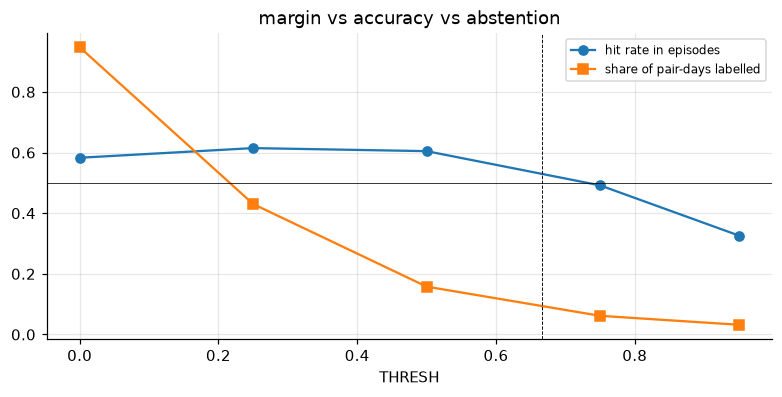

THRESH,labelled_episode_days,hit_rate,labelled_share_overall
f64,i64,f64,f64
0.0,7976,0.583,0.947
0.25,4023,0.615,0.43
0.5,1667,0.605,0.158
0.75,671,0.492,0.062
0.95,380,0.326,0.032


In [8]:
# threshold sensitivity: stricter margins should abstain more and hit more, if the confidence means anything
rows = []
for th in (0.0, 0.25, 0.5, 0.75, 0.95):
    lab_t = np.where((CONF >= th) & (CONF > 0), np.sign(DEV), np.nan)
    h = n = 0
    for up_, down_, s, e in EPISODES:
        if e > DATES[-1]:
            continue
        j, sign_up = pair_of[up_]
        l_ = lab_t[(DATES >= s) & (DATES <= e), j]; l_ = l_[~np.isnan(l_)]
        h += int((l_ == sign_up).sum()); n += l_.size
    rows.append({"THRESH": th, "labelled_episode_days": n, "hit_rate": h / n if n else np.nan,
                 "labelled_share_overall": float(np.mean(~np.isnan(lab_t)))})
SENS = pl.DataFrame(rows)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(SENS["THRESH"], SENS["hit_rate"], marker="o", label="hit rate in episodes")
ax.plot(SENS["THRESH"], SENS["labelled_share_overall"], marker="s", label="share of pair-days labelled")
ax.axhline(0.5, color="k", lw=0.5); ax.axvline(THRESH, color="k", ls="--", lw=0.6)
ax.set_xlabel("THRESH"); ax.legend(fontsize=8); ax.set_title("margin vs accuracy vs abstention")
plt.show()
SENS.with_columns(pl.selectors.float().round(3))

### 5.2 Labels during the three crises

Per crisis: the pairs that carry a declared episode, labels per day (red = pole a, blue = pole b,
white = unclear). Pole a is the alphabetical first pole of the pair (named on the y axis).

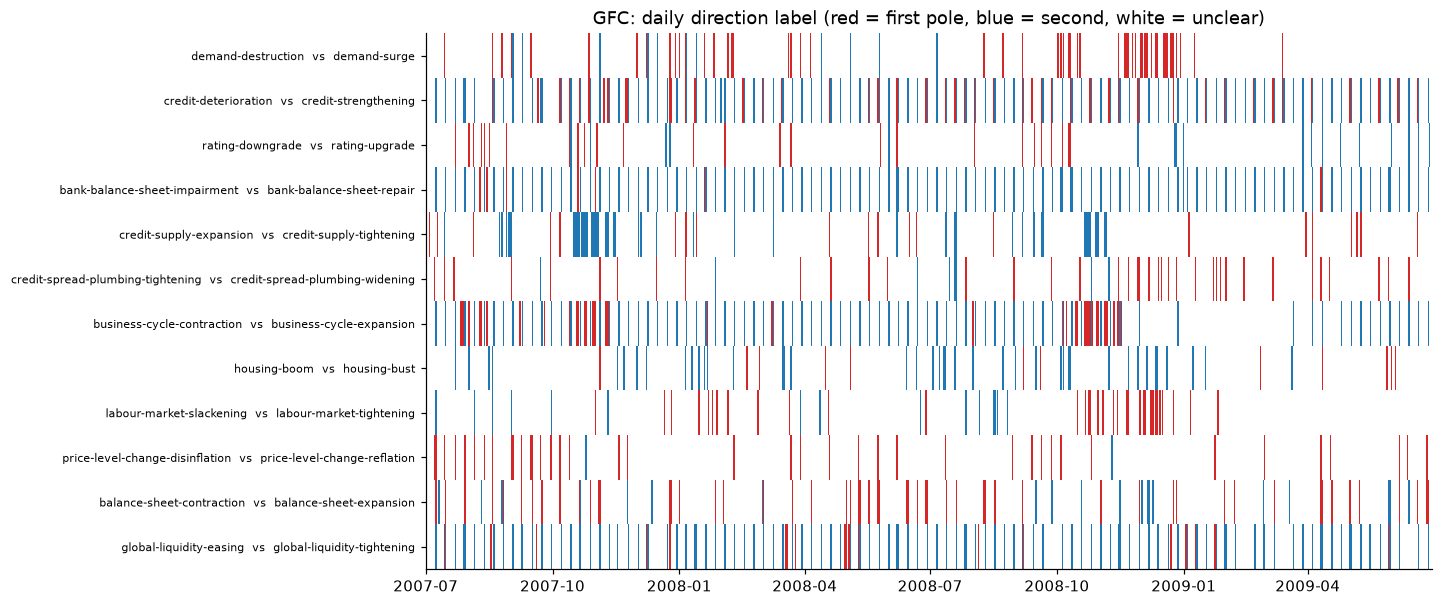

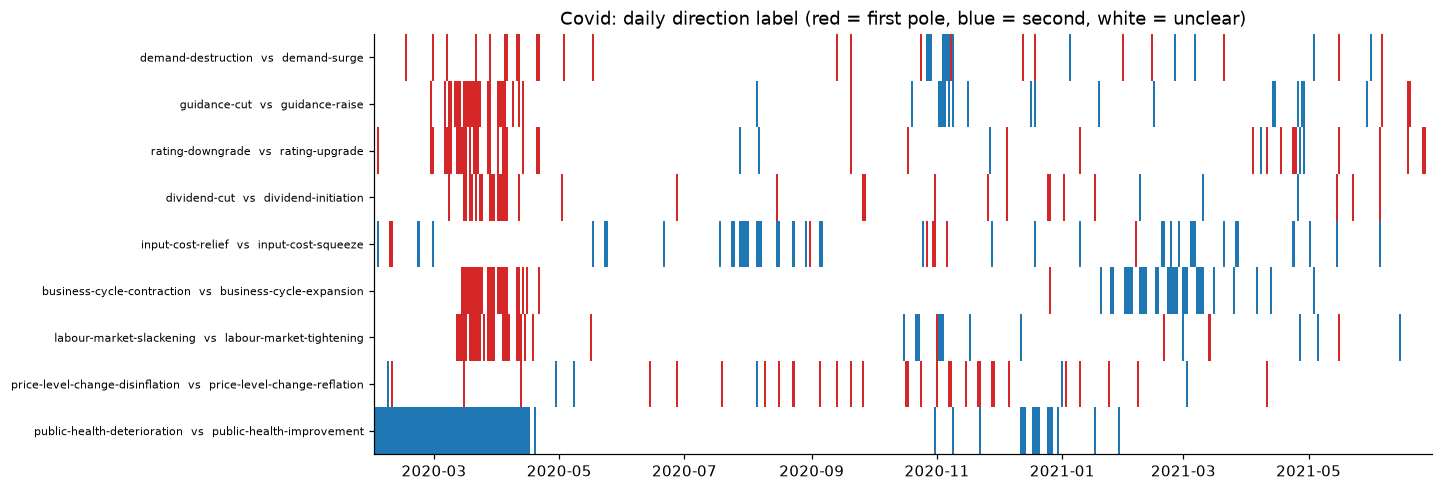

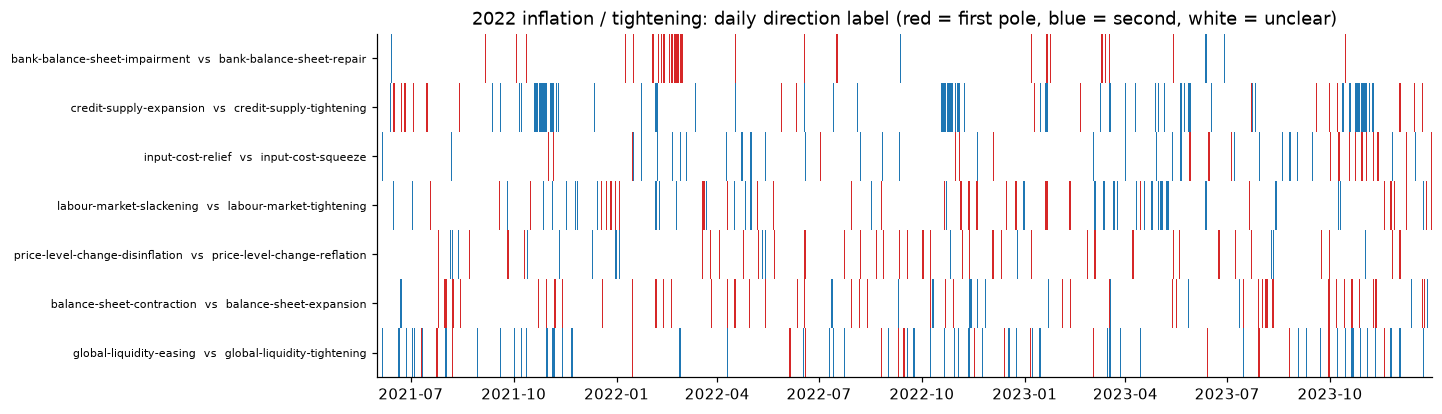

In [9]:
cmap = ListedColormap(["tab:blue", "white", "tab:red"])
for name, (lo, hi) in CRISES.items():
    if lo > DATES[-1]:
        continue
    js = sorted({pair_of[u][0] for u, d_, s, e in EPISODES if s <= hi and e >= lo})
    m = (DATES >= lo) & (DATES <= hi)
    M = np.nan_to_num(LABEL[m][:, js], nan=0.0)
    x = mdates.date2num(DATES[m].tolist())
    fig, ax = plt.subplots(figsize=(13, 0.35 * len(js) + 1.2))
    ax.imshow(M.T, aspect="auto", cmap=cmap, vmin=-1, vmax=1, interpolation="nearest",
              extent=[x[0], x[-1], len(js) - 0.5, -0.5])
    ax.set_yticks(range(len(js)), [f"{PAIRS['a'][j]}  vs  {PAIRS['b'][j]}" for j in js], fontsize=7)
    ax.xaxis_date(); ax.grid(False)
    ax.set_title(f"{name}: daily direction label (red = first pole, blue = second, white = unclear)")
    plt.show()

### 5.3 Crisis batteries on the un-polar columns

Battery attention (sum over its narratives) relative to the 2 years before the crisis, weekly mean.
"pole level" sums the listed poles as today; "un-polar" replaces every pole by its pair's topic column
(so a pair enters once), other narratives unchanged.

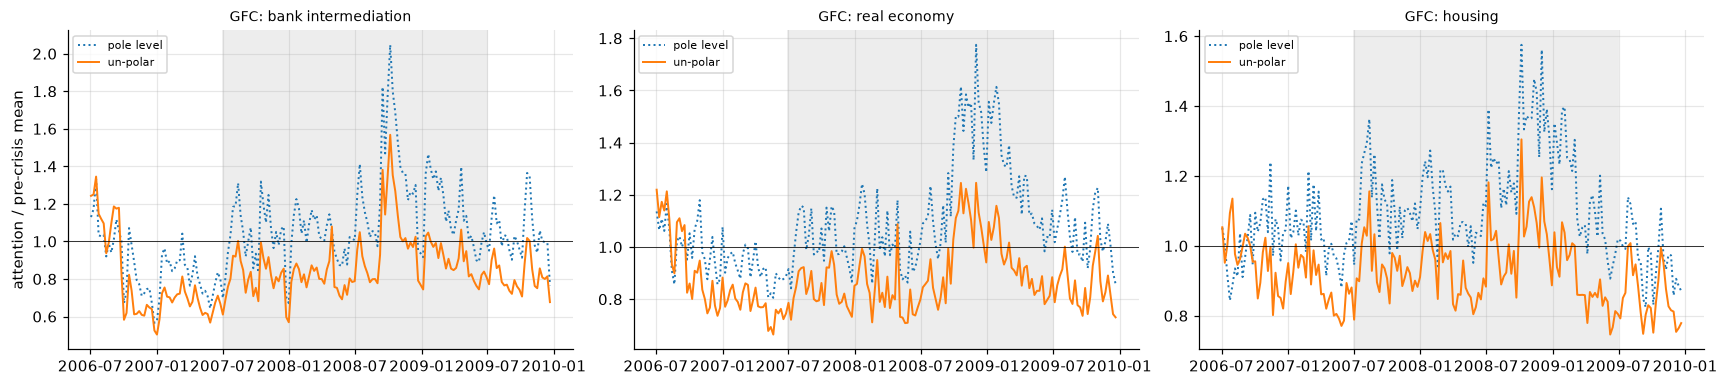

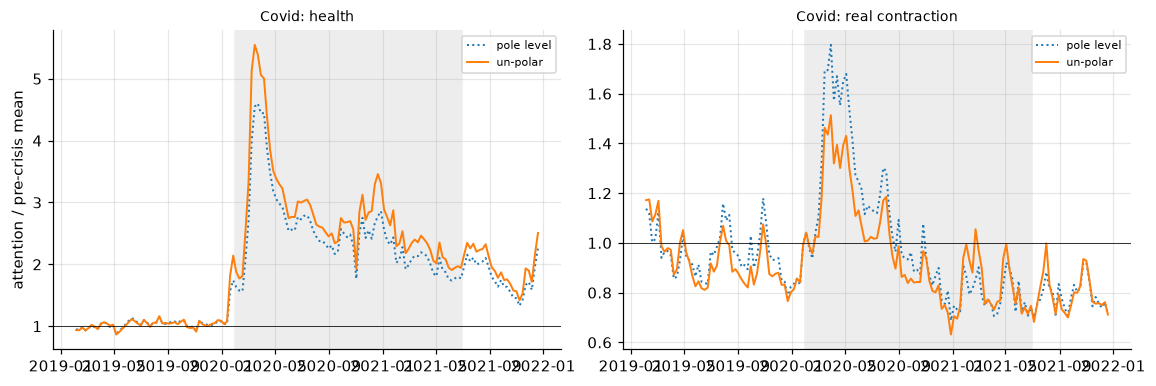

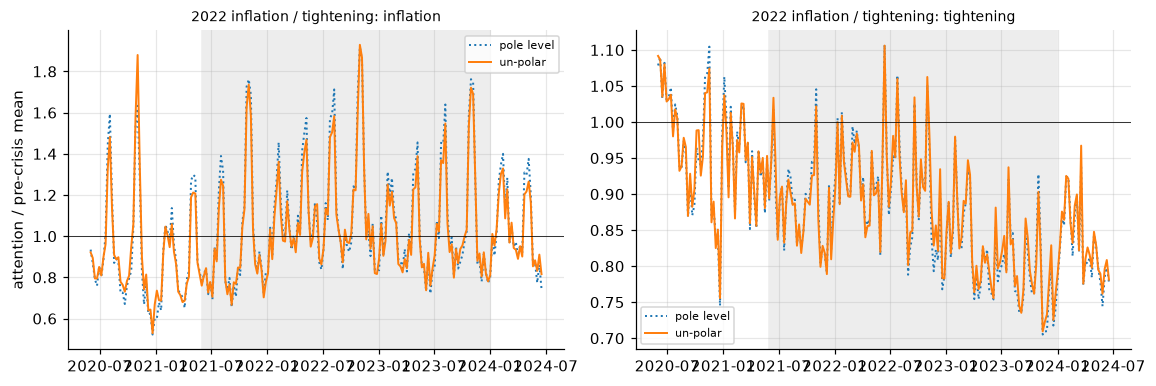

In [10]:
missing = [n for bats in BATTERIES.values() for ns in bats.values() for n in ns if n not in name_keys]
assert not missing, f"battery names not in the panel: {missing}"


def battery_series(names, unpolar):
    cols, seen = [], set()
    for n in names:
        if unpolar and n in pair_of:
            j = pair_of[n][0]
            if j not in seen:
                cols.append(TOPIC[:, j]); seen.add(j)
        else:
            cols.extend(TH[:, kidx[k]] for k in name_keys.get(n, []))
    return np.nansum(np.stack(cols, axis=1), axis=1)


for crisis, bats in BATTERIES.items():
    lo, hi = CRISES[crisis]
    if lo > DATES[-1]:
        continue
    fig, axes = plt.subplots(1, len(bats), figsize=(5.2 * len(bats), 3.4), squeeze=False)
    base = (DATES >= lo - timedelta(days=365 * BASELINE_YEARS)) & (DATES < lo)
    view = (DATES >= lo - timedelta(days=365)) & (DATES <= hi + timedelta(days=180))
    for ax, (bn, names) in zip(axes[0], bats.items()):
        for unpolar, st in ((False, ":"), (True, "-")):
            x = battery_series(names, unpolar)
            r = x / np.nanmean(x[base])
            w_, v_ = weekly(np.where(view, r, np.nan)); keep = ~np.isnan(v_)
            ax.plot(w_[keep], v_[keep], ls=st, lw=1.3, label="un-polar" if unpolar else "pole level")
        ax.axhline(1, color="k", lw=0.5); ax.axvspan(lo, hi, color="0.93")
        ax.set_title(f"{crisis}: {bn}", fontsize=9); ax.legend(fontsize=7)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    axes[0][0].set_ylabel("attention / pre-crisis mean")
    plt.show()

### 5.4 Which pairs are usable?

Per pair: share of days with a label over the whole sample and in the calm period, and the hit rate over
its declared episodes. "usable" = at least `USABLE_MIN_DAYS` labelled episode days and a hit rate
≥ `USABLE_HIT`; "wrong way" = enough days and hit rate < 50 %; pairs without a declared episode are
**untested**. Untested does not mean usable.

In [11]:
rows = []
for j, r in enumerate(PAIRS.iter_rows(named=True)):
    h = n = 0
    for up_, down_, s, e in EPISODES:
        if e > DATES[-1] or pair_of[up_][0] != j:
            continue
        l_ = LABEL[(DATES >= s) & (DATES <= e), j]; l_ = l_[~np.isnan(l_)]
        h += int((l_ == pair_of[up_][1]).sum()); n += l_.size
    hit = h / n if n else np.nan
    verdict = ("untested" if n == 0 else "too few labelled days" if n < USABLE_MIN_DAYS
               else "usable" if hit >= USABLE_HIT else "wrong way" if hit < 0.5 else "weak")
    rows.append({"pair": r["pair"], "a": r["a"], "b": r["b"], "labelled_share": float(np.mean(~np.isnan(LABEL[:, j]))),
                 "labelled_share_calm": float(np.mean(~np.isnan(LABEL[calm, j]))),
                 "episode_labelled_days": n, "episode_hit_rate": hit, "verdict": verdict})
PT = pl.DataFrame(rows).sort("verdict", "episode_hit_rate", descending=[False, True], nulls_last=True)
print(PT["verdict"].value_counts().sort("verdict"))
PT.with_columns(pl.selectors.float().round(3))

shape: (5, 2)
┌───────────────────────┬───────┐
│ verdict               ┆ count │
│ ---                   ┆ ---   │
│ str                   ┆ u32   │
╞═══════════════════════╪═══════╡
│ too few labelled days ┆ 4     │
│ untested              ┆ 35    │
│ usable                ┆ 5     │
│ weak                  ┆ 3     │
│ wrong way             ┆ 4     │
└───────────────────────┴───────┘


pair,a,b,labelled_share,labelled_share_calm,episode_labelled_days,episode_hit_rate,verdict
str,str,str,f64,f64,i64,f64,str
"""issuer-profitability:guidance""","""guidance-cut""","""guidance-raise""",0.066,0.045,24,1.0,"""too few labelled days"""
"""payout-policy:dividend""","""dividend-cut""","""dividend-initiation""",0.063,0.08,19,1.0,"""too few labelled days"""
"""sector-input-and-cost-condition:input-cost""","""input-cost-relief""","""input-cost-squeeze""",0.056,0.067,16,0.812,"""too few labelled days"""
"""yield-and-spread-plumbing:credit-spread-plumbing""","""credit-spread-plumbing-tightening""","""credit-spread-plumbing-widening""",0.06,0.082,20,0.1,"""too few labelled days"""
"""inventory-and-buffer-state:inventory""","""inventory-build""","""inventory-draw""",0.075,0.049,0,NaN,"""untested"""
"""precious-metal-physical-state:metal-supply""","""metal-supply-contraction""","""metal-supply-expansion""",0.103,0.056,0,NaN,"""untested"""
"""precious-metal-physical-state:physical-metal-demand""","""physical-metal-demand-strengthening""","""physical-metal-demand-weakening""",0.076,0.082,0,NaN,"""untested"""
"""precious-metal-physical-state:precious-metal-price""","""precious-metal-price-decline""","""precious-metal-price-rise""",0.066,0.08,0,NaN,"""untested"""
"""resource-price-and-volatility:curve""","""curve-backwardation""","""curve-contango""",0.056,0.083,0,NaN,"""untested"""


## 6. Summary

The cell below prints the numbers this summary rests on; read them against the reading guide.

* **What the rule keeps**: a direction only on pair-days whose balance moves clearly away from the pair's
  own normal split; everything else is "unclear" (NaN).
* **What to check**: (i) the episode hit rate should rise with `THRESH` (section 5.1 sensitivity); if it
  does not, the confidence is not measuring direction; (ii) the calm-period labelled share is the price
  in false alarms; (iii) the un-polar batteries should keep the crisis shapes of the pole-level ones.
* **Limits**: episodes cover about a third of the pairs; the rest are untested. The balance of a pair
  moves with the direction of the news *and* with any drift in how the scorer splits a topic between
  its poles; the trailing median absorbs slow drift but not sudden changes. Support counts a headline
  assigned to both poles twice.

In [12]:
print(f"pairs: {PAIRS.height}; labelled pair-days overall {np.mean(~np.isnan(LABEL)):.1%}, calm {np.mean(~np.isnan(LABEL[calm])):.1%}")
print(f"episode hit rate (labelled-day weighted) at THRESH={THRESH}: {w_hit:.1%} over {int(tot['labelled_days'].sum())} labelled days")
print("pair verdicts:", dict(PT["verdict"].value_counts().sort("verdict").iter_rows()))
print("usable:", PT.filter(pl.col("verdict") == "usable")["pair"].to_list())
print("wrong way:", PT.filter(pl.col("verdict") == "wrong way")["pair"].to_list())

pairs: 51; labelled pair-days overall 8.3%, calm 7.9%
episode hit rate (labelled-day weighted) at THRESH=0.6666666666666666: 54.3% over 904 labelled days
pair verdicts: {'too few labelled days': 4, 'untested': 35, 'usable': 5, 'weak': 3, 'wrong way': 4}
usable: ['resource-demand-condition:demand', 'housing-cycle:housing', 'intermediation-capacity:credit-supply', 'labour-market-slack:labour-market', 'issuer-solvency-and-distress:rating']
wrong way: ['cross-border-monetary-conditions:global-liquidity', 'issuer-solvency-and-distress:credit', 'public-health-condition:public-health', 'intermediation-capacity:bank-balance-sheet']
